In [ ]:
import numpy as np 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,Normalization,Flatten


In [7]:
#laoding dataser
from keras.datasets import mnist
(x_train,y_train),(x_test,y_test)=mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 12s 1us/step


In [9]:
print(x_train.shape,",",y_train.shape)
print(x_test.shape,",",y_test.shape)

(60000, 28, 28) , (60000,)
(10000, 28, 28) , (10000,)


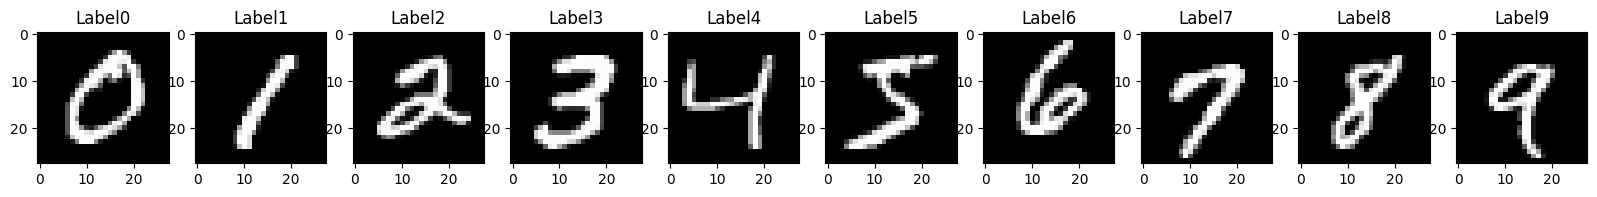

In [32]:
import matplotlib.pyplot as plt
num_of_digits=10
fig,ax=plt.subplots(1,num_of_digits,figsize=(20,20))
for i in range (0,num_of_digits):
    sample=x_train[y_train==i][0]
    ax[i].imshow(sample,cmap='grey')
    ax[i].set_title(f"Label{i}")



In [33]:
for i in range (10):
    print(y_train[i])

5
0
4
1
9
2
1
3
1
4


In [35]:
#converting discrete data into categorail
from keras.utils import to_categorical
to_categorical(y_train,num_of_digits)
to_categorical(y_test,num_of_digits)

array([[0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(10000, 10))

In [36]:
#normalization
norm=Normalization(axis=None)
norm.adapt(x_train)
x_train_norm=norm(x_train)
x_test_norm=norm(x_test)

In [39]:
print(x_test_norm[0,:10,:10])

tf.Tensor(
[[-0.42407387 -0.42407387 -0.42407387 -0.42407387 -0.42407387 -0.42407387
  -0.42407387 -0.42407387 -0.42407387 -0.42407387]
 [-0.42407387 -0.42407387 -0.42407387 -0.42407387 -0.42407387 -0.42407387
  -0.42407387 -0.42407387 -0.42407387 -0.42407387]
 [-0.42407387 -0.42407387 -0.42407387 -0.42407387 -0.42407387 -0.42407387
  -0.42407387 -0.42407387 -0.42407387 -0.42407387]
 [-0.42407387 -0.42407387 -0.42407387 -0.42407387 -0.42407387 -0.42407387
  -0.42407387 -0.42407387 -0.42407387 -0.42407387]
 [-0.42407387 -0.42407387 -0.42407387 -0.42407387 -0.42407387 -0.42407387
  -0.42407387 -0.42407387 -0.42407387 -0.42407387]
 [-0.42407387 -0.42407387 -0.42407387 -0.42407387 -0.42407387 -0.42407387
  -0.42407387 -0.42407387 -0.42407387 -0.42407387]
 [-0.42407387 -0.42407387 -0.42407387 -0.42407387 -0.42407387 -0.42407387
  -0.42407387 -0.42407387 -0.42407387 -0.42407387]
 [-0.42407387 -0.42407387 -0.42407387 -0.42407387 -0.42407387 -0.42407387
   0.6450706   1.9305896   1.599664    1

In [52]:
model=Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128,activation="relu"),
    Dropout(0.2),
    Dense(10,activation="linear")
])

C:\Users\ahmad\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [53]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import tensorflow.keras
model.compile(
    optimizer=tensorflow.keras.optimizers.Adam(learning_rate=0.001),
    loss=tensorflow.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [94]:
model.fit(x_train_norm,y_train,epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9442 - loss: 0.2007
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9447 - loss: 0.1980
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9422 - loss: 0.2066
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9450 - loss: 0.1956
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9448 - loss: 0.2048
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9457 - loss: 0.1941
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9452 - loss: 0.1955
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9456 - loss: 0.1955
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9453 - loss: 0.1987
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9460 - loss: 0.1936


In [91]:
logits=model(x_test_norm)
output=tensorflow.nn.softmax(logits)
output_class=np.argmax(output,axis=1)

In [92]:
print(output)
print(output_class)

tf.Tensor(
[[0.0000000e+00 0.0000000e+00 7.3518524e-13 ... 1.0000000e+00
  0.0000000e+00 4.0253864e-21]
 [0.0000000e+00 3.3242652e-14 1.0000000e+00 ... 0.0000000e+00
  7.0584776e-34 0.0000000e+00]
 [0.0000000e+00 1.0000000e+00 2.5250591e-10 ... 1.6947928e-09
  7.6963322e-13 7.5146551e-19]
 ...
 [0.0000000e+00 1.6688600e-18 4.1345708e-16 ... 2.9563049e-12
  3.9331027e-19 4.0516621e-09]
 [0.0000000e+00 0.0000000e+00 0.0000000e+00 ... 3.0686125e-26
  7.1244485e-21 3.5254476e-20]
 [0.0000000e+00 0.0000000e+00 0.0000000e+00 ... 0.0000000e+00
  0.0000000e+00 0.0000000e+00]], shape=(10000, 10), dtype=float32)
[7 2 1 ... 4 5 6]


In [95]:
test_loss, test_acc = model.evaluate(x_test_norm, y_test)
print(f"Loss: {test_loss}, Accuracy: {test_acc}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9545 - loss: 0.3169
Loss: 0.3169196546077728, Accuracy: 0.9545000195503235


In [87]:
import pickle
with open ("mnist_moedel.pkl","wb") as f:
    pickle.dump(model,f)

In [96]:
model.save('mnist_model.keras')